In [14]:
import numpy as np
import matplotlib.pyplot as plt
from solvers.background import solve_tov, eos, real_eos
from scipy.interpolate import interp1d
from IPython.display import display, Markdown
plt.style.use('seaborn-v0_8-whitegrid')

In [18]:
#Load Newtonian Data
data = np.load("newtonian.npz")

x_newt = data['x']
rho_newt = data['rho_hat']
P_newt = data['P_hat']

In [22]:
Pc = 1e-4 #Θα το δικαιλογησω απο geometrized units

R_tov, M_tov, sol = solve_tov(Pc, EoS=eos)
display(Markdown(rf"Η ακτίνα του άστρου είναι **{R_tov:.2f}** km"))
display(Markdown(rf"Η μάζα του άστρου είναι **{M_tov/1.4766:.2f}** $M_\odot$"))

Η ακτίνα του άστρου είναι **10.04** km

Η μάζα του άστρου είναι **0.86** $M_\odot$

In [23]:
def get_dimensionless(M,R,sol):

    r = np.linspace(1e-2,R,100)
    m = sol.sol(r)[0]
    P = sol.sol(r)[1]

    rho = eos(P)

    #Dimensionless
    x = r/R 
    rho_hat = ((4/3)*np.pi * R**3)/(M)*rho
    P_hat = (4*np.pi*R**4)/(M**2)* P
    m_hat = m/M

    return x,rho_hat,P_hat,m_hat



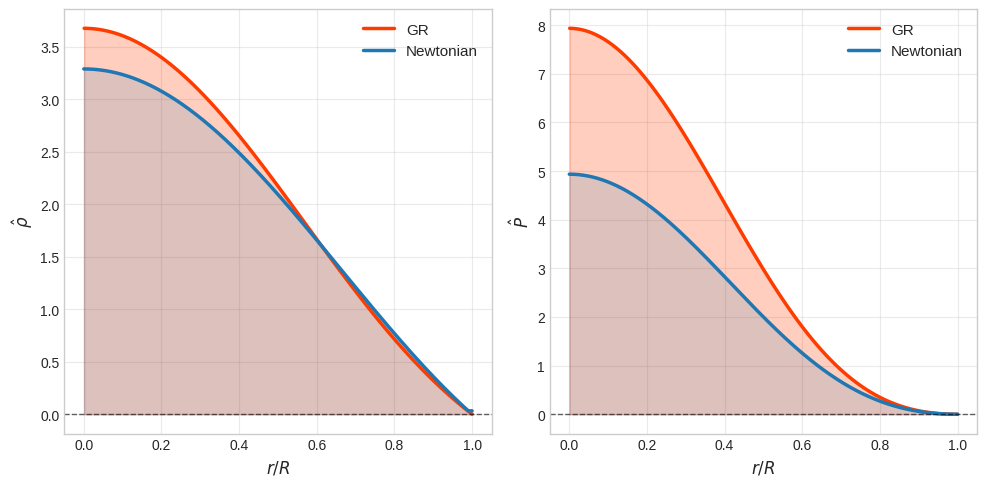

In [24]:
x, rho_tov, P_tov, m_tov = get_dimensionless(M_tov, R_tov,sol)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

fig, axes = plt.subplots(1,2, figsize=(10, 5))
quantities = {
    r"$\hat{\rho}$": (rho_tov, rho_newt),
    r"$\hat{P}$": (P_tov,P_newt)
}
gr_color = "#ff3c00ff" 
newt_color = '#1f77b4' 
for ax, (label, (qty_tov, qty_newt)) in zip(axes.flatten(), quantities.items()):
    
    ax.plot(x, qty_tov, linewidth=2.5, color=gr_color, label="GR")
    ax.plot(x_newt, qty_newt, linewidth=2.5, color=newt_color, label="Newtonian")
   
    ax.fill_between(x, qty_tov, 0, color=gr_color, alpha=0.25)
    ax.fill_between(x_newt, qty_newt, 0, color=newt_color, alpha=0.15)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_xlabel(r'$r/R$')
    ax.set_ylabel(label)
    ax.legend()
    
    ax.grid(True, alpha=0.4, linestyle='-')

plt.tight_layout()
plt.savefig('background_TOV(Γ=2).png', bbox_inches='tight')
plt.show()

In [26]:
#M-R diagram for Γ=2

Pc_values = np.logspace(-5,-1,50)
M_list = []
R_list = []

for Pc in Pc_values:
    R,M,sol = solve_tov(Pc,EoS=eos)
    Msolar = M/1.4766
    M_list.append(Msolar)
    R_list.append(R)


/home/vaggelis/Desktop/Πτυχιακη/Kwdikas/solvers/background.py:52: RuntimeWarning: invalid value encountered in scalar power
  return (P/K)**(1/G) + P/(G-1)


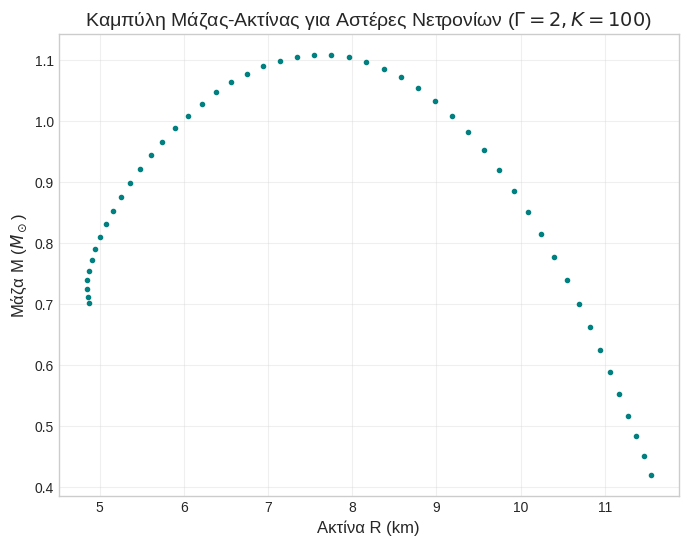

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(R_list, M_list, marker='.', color='teal')
plt.xlabel('Ακτίνα R (km)', fontsize=12)
plt.ylabel(r'Μάζα M ($M_\odot$)', fontsize=12)
plt.title(r'Καμπύλη Μάζας-Ακτίνας για Αστέρες Νετρονίων ($\Gamma=2, K=100$)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig("M-R_g=2.png")
plt.show()

In [54]:
#Ρεαλιστική EoS όπως στο paper των OV
t = np.linspace(1e-5,5,1000)
rho_real, P_real = real_eos(t)

eos_real = interp1d(P_real,rho_real, kind="cubic", fill_value="extrapolate")


In [55]:
Pc=1e-3
R_real,M_real,sol_real = solve_tov(Pc,eos_real)
display(Markdown(rf"Η ακτίνα του άστρου είναι **{R_real:.2f}** km"))
display(Markdown(rf"Η μάζα του άστρου είναι **{M_real/1.4766:.2f}** $M_\odot$"))

Η ακτίνα του άστρου είναι **7.42** km

Η μάζα του άστρου είναι **0.68** $M_\odot$

In [56]:
#M-R diagram for real EoS

Pc_values = np.logspace(-5,-1,50)
M_list = []
R_list = []

for Pc in Pc_values:
    R,M,sol = solve_tov(Pc,EoS=eos_real)
    Msolar = M/1.4766
    M_list.append(Msolar)
    R_list.append(R)


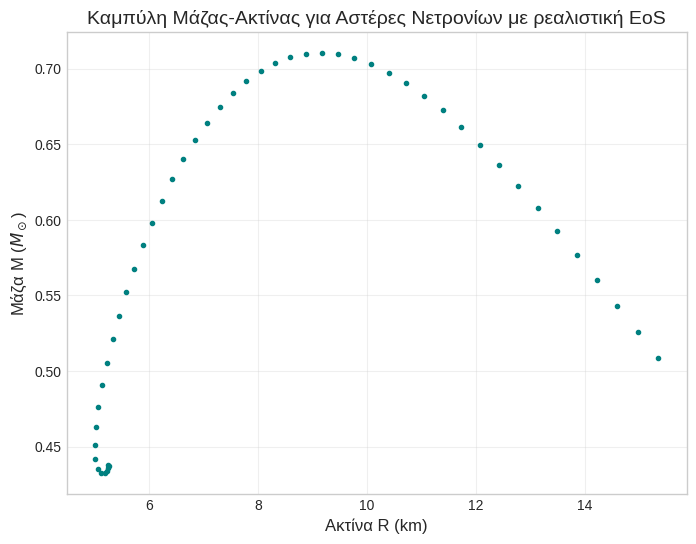

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(R_list, M_list, marker='.', color='teal')
plt.xlabel('Ακτίνα R (km)', fontsize=12)
plt.ylabel(r'Μάζα M ($M_\odot$)', fontsize=12)
plt.title(r'Καμπύλη Μάζας-Ακτίνας για Αστέρες Νετρονίων με ρεαλιστική EoS', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig("M-R_real.png")
plt.show()